# Case Study Assessment — NYC Airbnb Data Preprocessing
### Student Name:Raniya Amanulla
### Date:29/09/26

This notebook is your submission template. Fill in each section — do not delete the headers. Use markdown cells for your written justifications, right next to the code that supports them.

In [101]:
import pandas as pd
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


---
## Part 1 — Data Understanding & Quality Audit

In [102]:
# TODO: shape, dtypes, missing value summary
df.shape

(48895, 16)

In [103]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [104]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [105]:
# TODO: check for values that are technically present but don't make real-world sense
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [106]:
print('price 0 count : ' , (df['price'] == 0).sum())

price 0 count :  11


In [107]:
print('min nights 0 count : ' ,(df['minimum_nights'] == 0).sum())

min nights 0 count :  0


In [108]:
print('availability > 365 count: ',(df['availability_365'] >365).sum())

availability > 365 count:  0


In [109]:
# TODO: duplicate check
df.duplicated().sum()

np.int64(0)

**Written notes — what did you find, and what looks suspicious?**

_This data has 48895 and 16 columns .I found missing values only in last_review and reviews per month (10052 each).For suspicious values , I found 11 listings where price is 0,which is not possible . price max is 1000 which is an outlier.last review datatype is an object.minimum_nights have max 1250. No duplicate rows found ._

---
## Part 2 — Missing Value Diagnosis & Treatment

In [110]:
# TODO: investigate missingness pattern(s) across columns
df['last_review'].isna().sum()

np.int64(10052)

In [111]:
df['reviews_per_month'].isna().sum()

np.int64(10052)

**Written justification — MCAR / MAR / MNAR classification per column, and your reasoning:**

_Number of missing values in both columns are  same because there is no reviews and hence no last review date.so Iam going to  drop the column review_per_month & last review because more than 20% are missing._

In [112]:
# TODO: apply your chosen treatment(s)
df=df.drop(['last_review','reviews_per_month','id','host_id','host_name','name'],axis = 1)

In [113]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


**Written justification — why this treatment for each column, and what you'd risk with `dropna()` instead:**

_I droped both column because more the 20% data is missing in these columns so it is better to drop it. If I used dropna() i would lose 10052 rows and delete all new houses._

---
## Part 3 — Outlier Detection & Treatment

In [114]:
# TODO: detect outliers in at least two numeric columns
df.columns

Index(['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365'],
      dtype='object')

<Axes: >

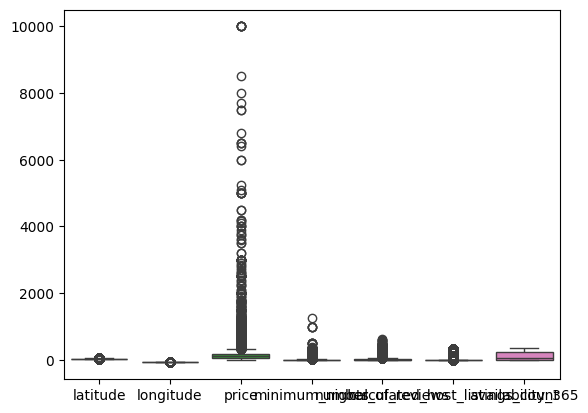

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(df[['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude',
       'room_type', 'price', 'minimum_nights', 'number_of_reviews',
       'calculated_host_listings_count', 'availability_365']])

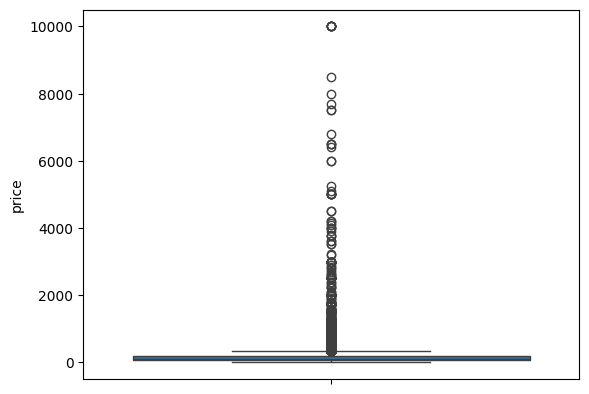

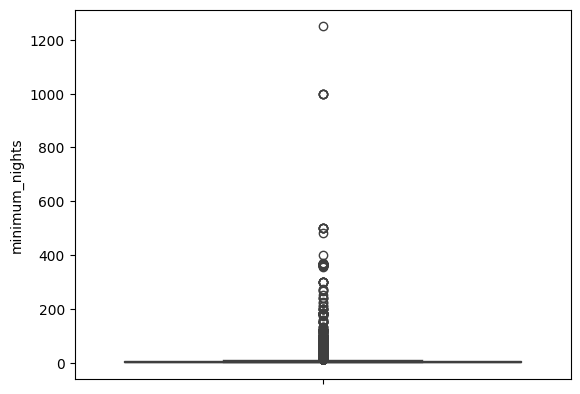

In [116]:
sns.boxplot(df['price'])
plt.show()
sns.boxplot(df['minimum_nights'])
plt.show()

**Written justification — for each outlier group, is it an error or a genuine listing? What evidence supports your call?**

_in case of price 0 is definitely an error and 10000 s a huge value so i'm going  to cap each values not to the lower limit and upper limit but minimum 30 and maximum 2000 dollars.As for minimum nights i'm going to cap the outliers to lower limit and upper limit  ._

In [117]:
# TODO: apply treatment consistent with your judgment above
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

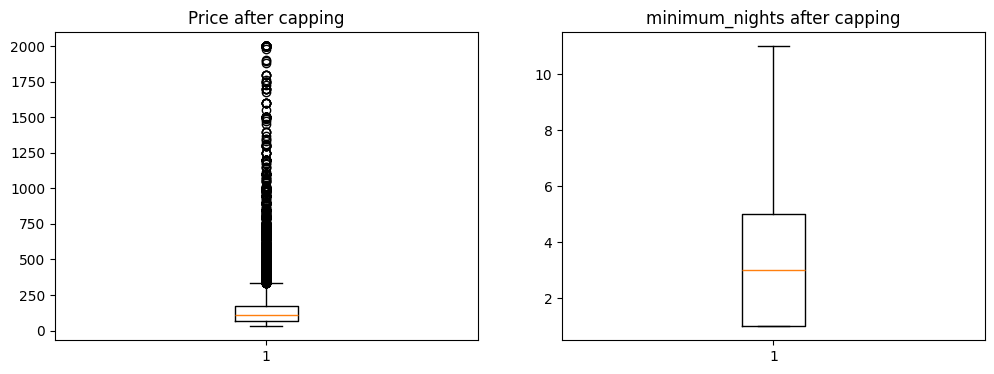

In [118]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.boxplot(df['price'])
plt.title('Price after capping')

plt.subplot(1,2,2)
plt.boxplot(df['minimum_nights'])
plt.title('minimum_nights after capping')

plt.show()

---
## Part 4 — Feature Engineering & Encoding

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 10 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  object 
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   calculated_host_listings_count  48895 non-null  int64  
 9   availability_365                48895 non-null  int64  
dtypes: float64(2), int64(5), object(3)
memory usage: 3.7+ MB


In [120]:
# TODO: encode categorical columns appropriately
df['neighbourhood'].unique()

array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',
       'Murray Hill', 'Bedford-Stuyvesant', "Hell's Kitchen",
       'Upper West Side', 'Chinatown', 'South Slope', 'West Village',
       'Williamsburg', 'Fort Greene', 'Chelsea', 'Crown Heights',
       'Park Slope', 'Windsor Terrace', 'Inwood', 'East Village',
       'Greenpoint', 'Bushwick', 'Flatbush', 'Lower East Side',
       'Prospect-Lefferts Gardens', 'Long Island City', 'Kips Bay',
       'SoHo', 'Upper East Side', 'Prospect Heights',
       'Washington Heights', 'Woodside', 'Brooklyn Heights',
       'Carroll Gardens', 'Gowanus', 'Flatlands', 'Cobble Hill',
       'Flushing', 'Boerum Hill', 'Sunnyside', 'DUMBO', 'St. George',
       'Highbridge', 'Financial District', 'Ridgewood',
       'Morningside Heights', 'Jamaica', 'Middle Village', 'NoHo',
       'Ditmars Steinway', 'Flatiron District', 'Roosevelt Island',
       'Greenwich Village', 'Little Italy', 'East Flatbush',
       'Tompkinsville', 'Asto

In [121]:

frequency = df['neighbourhood'].value_counts()

df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [122]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365
0,Brooklyn,175,40.64749,-73.97237,Private room,149,1,9,6,365
1,Manhattan,1545,40.75362,-73.98377,Entire home/apt,225,1,45,2,355
2,Manhattan,2658,40.80902,-73.94190,Private room,150,3,0,1,365
3,Brooklyn,572,40.68514,-73.95976,Entire home/apt,89,1,270,1,194
4,Manhattan,1117,40.79851,-73.94399,Entire home/apt,80,10,9,1,0


In [123]:
df['room_type'].unique()

array(['Private room', 'Entire home/apt', 'Shared room'], dtype=object)

In [124]:
# TODO: engineer at least two new features
from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Shared room', 'Private room', 'Entire home/apt']]
)
df['room_type']=encoder.fit_transform(df[['room_type']])

In [125]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [126]:
df=pd.get_dummies(df,prefix='group',dtype='int',drop_first=True)

In [127]:
df.head()

,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,calculated_host_listings_count,availability_365,group_Brooklyn,group_Manhattan,group_Queens,group_Staten Island
0,175,40.64749,-73.97237,1.0,149,1,9,6,365,1,0,0,0
1,1545,40.75362,-73.98377,2.0,225,1,45,2,355,0,1,0,0
2,2658,40.80902,-73.94190,1.0,150,3,0,1,365,0,1,0,0
3,572,40.68514,-73.95976,2.0,89,1,270,1,194,1,0,0,0
4,1117,40.79851,-73.94399,2.0,80,10,9,1,0,0,1,0,0


**Written justification — why these features, and which column(s) should NOT be used to predict price, and why:**

__First 4 columns are dropped they we id,name,host_id,host_name. They don't need to be present for prediction. other  object column were handled neighbourhood is handled by frequency encoder, room_type has ordinal data so ordinal encoding is done and for neighbourhood_group OneHotEncoding is done_._

---
## Part 5 — Build a Reusable Preprocessing Pipeline

In [128]:
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [129]:
# TODO: build Pipeline combining your cleaning, imputation, encoding, scaling steps
url = "https://raw.githubusercontent.com/erkansirin78/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(url)
df.head()
# Missing value handling and removing Unnecessary columns
df=df.drop(['last_review','id','name','host_id','host_name'],axis=1)
df['reviews_per_month']=df['reviews_per_month'].fillna(0)

In [130]:
# Outlier Management
# PRICE
df.loc[df['price']<30,'price']=30
df.loc[df['price']>2000,'price']=2000

#minimum_nights
q1 = df['minimum_nights'].quantile(0.25)
q3 = df['minimum_nights'].quantile(0.75)

iqr = q3 - q1

up_lim = q3 + (1.5 * iqr)
low_lim = q1 - (1.5 * iqr)

df.loc[df['minimum_nights']<low_lim,'minimum_nights']=low_lim
df.loc[df['minimum_nights']>up_lim,'minimum_nights']=up_lim

In [131]:
#Encoding:
# neighbourhood - frequency encoding,
frequency = df['neighbourhood'].value_counts()
df['neighbourhood'] = df['neighbourhood'].map(frequency)
print(df['neighbourhood'])

0         175
1        1545
2        2658
3         572
4        1117
         ... 
48890    3714
48891    2465
48892    2658
48893    1958
48894    1958
Name: neighbourhood, Length: 48895, dtype: int64


In [132]:
# TODO: train/test split (before fitting anything)

# Seperate X and Y
x = df.drop('price',axis=1)
y = df['price']

# Train_test split
x_train,x_test,y_train,y_test =train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             48895 non-null  object 
 1   neighbourhood                   48895 non-null  int64  
 2   latitude                        48895 non-null  float64
 3   longitude                       48895 non-null  float64
 4   room_type                       48895 non-null  object 
 5   price                           48895 non-null  int64  
 6   minimum_nights                  48895 non-null  int64  
 7   number_of_reviews               48895 non-null  int64  
 8   reviews_per_month               48895 non-null  float64
 9   calculated_host_listings_count  48895 non-null  int64  
 10  availability_365                48895 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 4.1+ MB


In [134]:
numerical_columns = ['neighbourhood','minimum_nights','number_of_reviews','reviews_per_month','calculated_host_listings_count','availability_365']
nominal_columns = ['neighbourhood_group']
ordinal_columns = ['room_type']

In [135]:
numerical_pipeline = Pipeline([
    ('scalar',StandardScaler())
])

In [136]:
nominal_pipeline = Pipeline([
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

In [137]:
ordinal_pipeline = Pipeline([
    ('encoder',OrdinalEncoder(
        categories=[['Shared room', 'Private room', 'Entire home/apt']]
    ))
])

In [138]:
# Combine Pipelines
preprocessor = ColumnTransformer([
    ('numeric',numerical_pipeline,numerical_columns),
    ('nominal',nominal_pipeline,nominal_columns),
    ('ordinal', ordinal_pipeline, ordinal_columns)
])

In [139]:
# Fit and transform training data
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

In [142]:
x_train

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
32645,Brooklyn,3920,40.71577,-73.95530,Entire home/apt,3,11,0.87,1,1
23615,Manhattan,899,40.84917,-73.94048,Private room,2,2,0.16,1,0
31183,Brooklyn,3714,40.68993,-73.95947,Private room,2,0,0.00,2,0
29260,Brooklyn,3714,40.68427,-73.93118,Entire home/apt,3,87,4.91,1,267
7275,Queens,235,40.74705,-73.89564,Private room,5,13,0.25,1,0
...,...,...,...,...,...,...,...,...,...,...
11284,Manhattan,899,40.84650,-73.94319,Shared room,1,0,0.00,1,0
44732,Manhattan,1113,40.73957,-74.00082,Private room,2,4,1.90,1,76
38158,Manhattan,1971,40.78318,-73.97372,Entire home/apt,11,1,0.34,5,261
860,Manhattan,1971,40.77508,-73.97990,Entire home/apt,2,11,0.13,1,2


In [140]:
x_train.shape

(39116, 10)

In [141]:
x_train_preprocessed.shape

(39116, 11)

---
## Part 6 — Written Reflection

1. _Dropping last_review must have effected on this process ._
2. Outlier capping was applied to price and minimum_nights to address extreme values (such as prices of $0 or $10,000, and minimum nights exceeding 1,000) that distort distribution statistics and disproportionately affect loss functions like RMSE. Setting custom boundaries for price ($ 30 to $2,000) and using IQR bounds for minimum_nights keeps extreme outliers from distorting model training while preserving all sample rows.._
3. Global transformations performed on the entire dataset prior to a train/test split cause severe data leakage . When summary statistics (such as IQR limits, frequency counts, standard scaling parameters, or imputing medians) are calculated using all 48,895 rows, information from the test set leaks directly into training features. This gives the model artificial context about the evaluation dataset, leading to over-optimistic performance during training that will fail to generalize to new, real-world data._